# Wstęp
##### Celem tej części projektu jest: Opracowanie modelu regresji do predykcji mediany cen mieszkań w Kaliforni
##### Skład zespołu: Konrad Wołkiewicz, Tymon Jażdżewski, Piotr Gawroński
##### Źródło danych: https://www.kaggle.com/datasets/camnugent/california-housing-prices/data


# Opracowanie Modelu Regresji

#### Wczytujemy potrzebne biblioteki

In [121]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

#### Wczytujemy dane i pozbywamy się sztucznie ograniczonych danych
W zbiorze danych zmienna docelowa median_house_value została sztucznie ograniczona od góry do wartości 500 001.00. Pozostawienie tych obserwacji wprowadziłoby obciążenie do modelu regresyjnego. 

In [122]:
df = pd.read_csv('data/housing_final.csv')
df = df[df['median_house_value'] != 500001.0]

#### Konwersja kolum True/False na typ int (1/0)

In [123]:
ocean_cols = [col for col in df.columns if 'ocean_proximity_' in col]
for col in ocean_cols:
    df[col] = df[col].astype(int)

#### Dzielimy zbiór danych na zbiór treningowy i testowy

In [124]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Ridge (L2) z CV
Wstępnie sprawdziliśy model Regresji Grzbietowej z regularyzacją L2 (Ridge) z wykorzystaniem techniki Cross Validation (CV).

Generujemy 30 wartości parametru regularyzacji - alpha w skali logarytmicznej od 0.001 do 1000. Od parametru alpha zależy siła regularyzacji.

* Niska wartość alpha: model dąży do działania jak zwykła regresja liniowa.
* Wysoka wartość alpha: model silnie obciąża współczynniki (wymusza ich wartość bliską 0), zmniejszając wariancję modelu kosztem obciążenia.


In [125]:
alphas = np.logspace(-3, 3, 30)

#### Potok przetwarzania danych: 

Budujemy potok przetwarzania (Pipeline) składający się z dwóch kroków:

1.  **StandardScaler**: Standaryzacja zmiennych wejściowych tak, aby ich średnia = 0 oraz ich odchylenie_standardowe = 1. Jest to kluczowy krok w modelach regresji
2.  **RidgeCV**: Model regresji z wbudowaną walidacją krzyżową. Parametr `cv=5` oznacza, że dla każdej wartości alpha
 model jest trenowany i walidowany 5-krotnie na różnych podzbiorach danych treningowych.



In [126]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])

#### Trenowanie modelu:

In [127]:
ridge.fit(X_train, y_train)

ridge_model = ridge.named_steps['ridge']
print(f"Ridge: wybrane alpha={ridge_model.alpha_:.4f}")

Ridge: wybrane alpha=8.5317


Algorytm znalazł optimum lokalne dla parametru **$\alpha = 8.5317$**. 

Jako metrykę ewaluacji modelu przyjęto **RMSE (Root Mean Squared Error)**. Obliczana jest ona osobno dla zbioru treningowego i testowego.

RIDGE (L2)
Train RMSE: $60,357.40
Test RMSE:  $62,455.10
Współczynniki Ridge (ważność cech):
median_income                 59304.429303
longitude                    -48428.386350
latitude                     -47846.200551
population                   -37398.531109
total_bedrooms                34467.832003
households                    20873.671235
ocean_proximity_INLAND       -18605.803071
total_rooms                  -13031.153234
housing_median_age            11676.831758
ocean_proximity_ISLAND         2898.107335
ocean_proximity_NEAR BAY      -2701.987978
ocean_proximity_NEAR OCEAN     1222.804256
dtype: float64


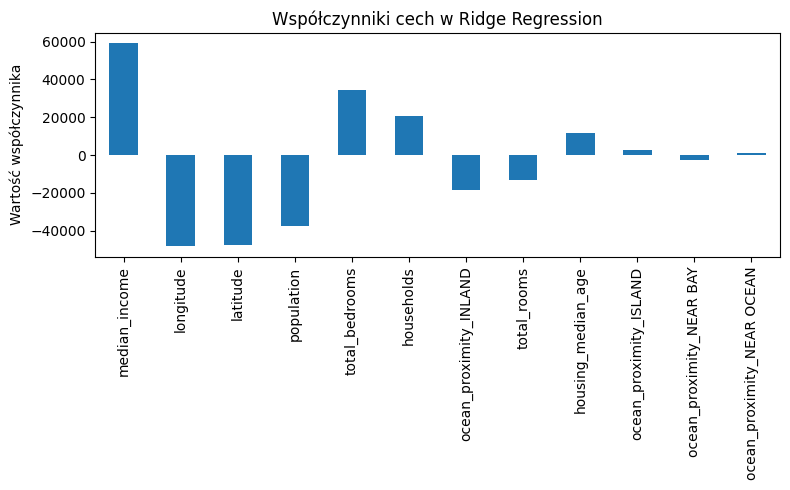

In [128]:
y_pred_train_ridge = ridge.predict(X_train)
y_pred_test_ridge  = ridge.predict(X_test)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge  = np.sqrt(mean_squared_error(y_test,  y_pred_test_ridge))

print("="*50)
print("RIDGE (L2)")
print("="*50)
print(f"Train RMSE: ${rmse_train_ridge:,.2f}")
print(f"Test RMSE:  ${rmse_test_ridge:,.2f}")
print("="*50)

coefs_ridge = pd.Series(ridge_model.coef_, index=X_train.columns)
coefs_ridge = coefs_ridge.sort_values(key=abs, ascending=False)
print("Współczynniki Ridge (ważność cech):")
print(coefs_ridge)

plt.figure(figsize=(8,5))
coefs_ridge.plot(kind='bar')
plt.title('Współczynniki cech w Ridge Regression')
plt.ylabel('Wartość współczynnika')
plt.tight_layout()
plt.show()


In [129]:
mean_price = df['median_house_value'].mean()
print(f"Średnia cena nieruchomości: ${mean_price:,.2f}")

Średnia cena nieruchomości: $192,477.92


#### Wnioski 

Na podstawie uzyskanych wyników można dojść do następujących konkluzji:

1. Niewielka rozbieżność między błędem RMSE na zbiorze treningowym ($60 357) a testowym ($62 455) dowodzi, że model jest stabilny i nie uległ zjawisku przeuczenia (*overfitting*).

2. Automatyczny dobór parametru $\alpha \approx 8.53$ wskazuje na konieczność zastosowania umiarkowanej regularyzacji. Fakt, że model odrzucił czystą regresję liniową (gdzie $\alpha \approx 0$), potwierdza występowanie w danych współliniowości (korelacji między cechami), którą algorytm Ridge skutecznie skorygował.

3. Analiza otrzymanych współczynników jednoznacznie potwierdza wstępną hipotezę badawczą. Dominującym czynnikiem wpływającym na cenę nieruchomości (`median_house_value`) jest zamożność mieszkańców (`median_income`), natomiast drugą kluczową determinantą pozostaje lokalizacja geograficzna.

4. Średnia wartość nieruchomości w badanym zbiorze wynosi **$192 477,92**. Błąd predykcji (RMSE) na poziomie **$62 455,10** stanowi zatem około **32,4%** średniej ceny. Jest to wynik akceptowalny dla modelu ogólnego.

## Decision Tree

Dzielimy zbiór danych na zbiór treningowy i testowy

In [130]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Generujemy 25 wartości parametru cpp_alpha w skali logarytmicznej (od $10^4$ do $10^8$). Parametr ten określa "karę" za złożoność drzewa. Im wyższa jego wartość, tym bardziej przycinamy gałęzie, aby uprościć model i zapobiec jego przeuczeniu.

In [131]:
ccp_alphas = np.logspace(4, 8, 25) 

#### Trenowanie i wybór optymalnego modelu:

Tworzymy pętlę, która dla każdej z 25 wartości z `ccp_alphas`:
* Trenuje pełne drzewo decyzyjne.
* Dokonuje predykcji na zbiorze treningowym i testowym.
* Oblicza błąd RMSE i zapisuje go do analizy.


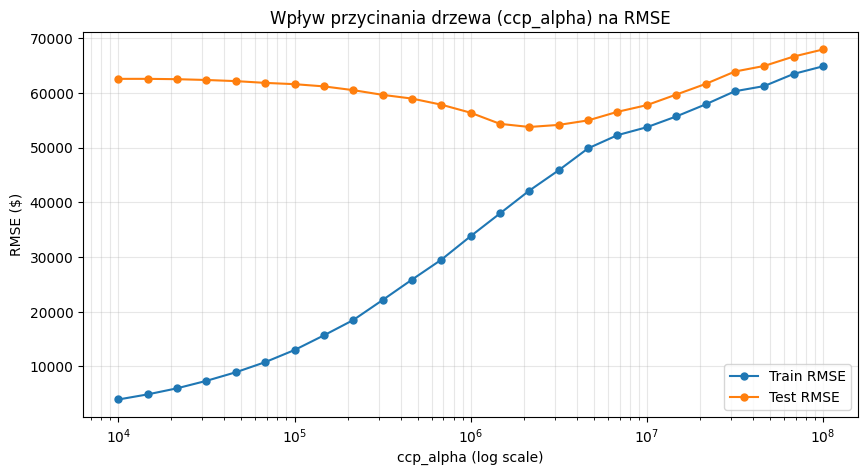

In [132]:
rmse_test_ccp = []
rmse_train_ccp = []

for ccp in ccp_alphas:
    tree = DecisionTreeRegressor(max_depth=None, random_state=42, ccp_alpha=ccp)
    tree.fit(X_train, y_train)
    y_pred_train = tree.predict(X_train)
    y_pred_test = tree.predict(X_test)
    rmse_train_ccp.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    rmse_test_ccp.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

plt.figure(figsize=(10,5))
plt.semilogx(ccp_alphas, rmse_train_ccp, label='Train RMSE', marker='o', markersize=5)
plt.semilogx(ccp_alphas, rmse_test_ccp, label='Test RMSE', marker='o', markersize=5)
plt.xlabel('ccp_alpha (log scale)')
plt.ylabel('RMSE ($)')
plt.title('Wpływ przycinania drzewa (ccp_alpha) na RMSE')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()

In [133]:
best_ccp = ccp_alphas[np.argmin(rmse_test_ccp)]
print(f'Optymalne ccp_alpha: {best_ccp:.2f}, Test RMSE: ${min(rmse_test_ccp):,.2f}')

Optymalne ccp_alpha: 2154434.69, Test RMSE: $53,754.05


Wybieramy najlepsze 'ccp_alpha' = 2154434.69

#### Wybór głębokości drzewa:

Sprawdzamy czy dobór parametru głębokości drzewa (`max_depth`) w połączeniu z wybranym wcześniej parametrem przycinania (`ccp_alpha`) poprawi wynik modelu. Tworzymy pętlę przechodzącą przez wszystkie możliwe wartości `max_depth` od 3 do 30 oraz wariant bez limitu (`None`). 

In [134]:
print("\n" + "="*50)
print("DECISION TREE - WYBÓR GŁĘBOKOŚCI")
print("="*50)

depths = [3, 5, 10, 15, 20, 30, None]
best_tree_depth = None
best_tree_score = float('inf')

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42, ccp_alpha=best_ccp)
    tree.fit(X_train, y_train)
    y_pred_test_temp = tree.predict(X_test)
    rmse_test_temp = np.sqrt(mean_squared_error(y_test, y_pred_test_temp))
    depth_str = str(depth) if depth else "None"
    print(f"Depth={depth_str:<4} | Test RMSE: ${rmse_test_temp:>10,.2f}")
    if rmse_test_temp < best_tree_score:
        best_tree_score = rmse_test_temp
        best_tree_depth = depth
        best_tree_model = tree

print(f"\nWybrano: max_depth={best_tree_depth}, Test RMSE=${best_tree_score:,.2f}")


DECISION TREE - WYBÓR GŁĘBOKOŚCI
Depth=3    | Test RMSE: $ 69,159.67
Depth=5    | Test RMSE: $ 64,350.84
Depth=10   | Test RMSE: $ 54,709.86
Depth=15   | Test RMSE: $ 53,768.07
Depth=20   | Test RMSE: $ 53,755.45
Depth=30   | Test RMSE: $ 53,699.35
Depth=None | Test RMSE: $ 53,754.05

Wybrano: max_depth=30, Test RMSE=$53,699.35


Najniższy błąd predykcji (RMSE) odnotowano dla parametru max_depth równego 30.

### Analiza Ważności Cech:

W celu analizy wpływu cech na predykcję pobieramy wagi cech z modelu `best_tree_model` i sortujemy je malejąco.


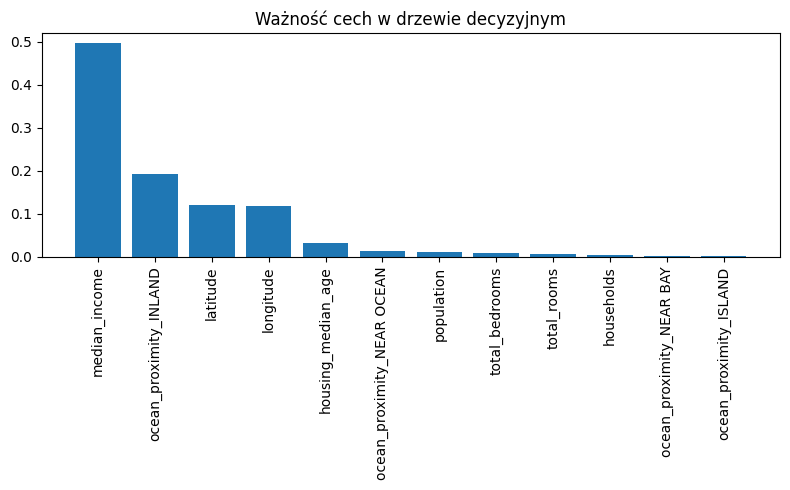

1. median_income: 0.4956
2. ocean_proximity_INLAND: 0.1920
3. latitude: 0.1201
4. longitude: 0.1171
5. housing_median_age: 0.0314
6. ocean_proximity_NEAR OCEAN: 0.0127
7. population: 0.0098
8. total_bedrooms: 0.0093
9. total_rooms: 0.0062
10. households: 0.0042


In [135]:
importances = best_tree_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(8,5))
plt.title("Ważność cech w drzewie decyzyjnym")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

Cechą o największym wpływie na predykcję pozostaje `median_income`. Potwierdza to stabilność tego czynnika niezależnie od wybranego algorytmu. Drugą najbardziej znaczącą cechą jest `ocean_proximity_INLAND`.

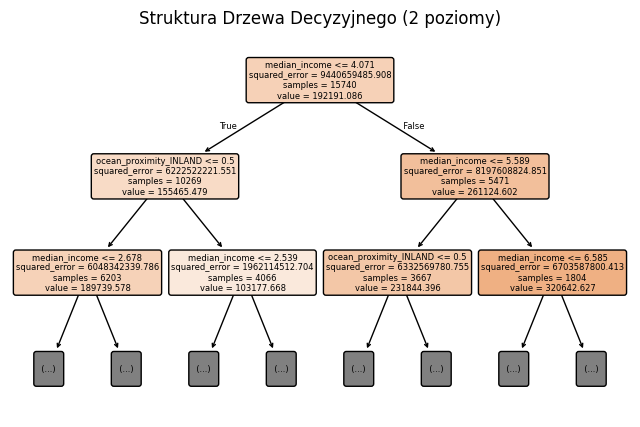

In [136]:
plt.figure(figsize=(8, 5))

plot_tree(best_tree_model, feature_names=X_train.columns, filled=True, rounded=True, max_depth=2, fontsize=6)

plt.title("Struktura Drzewa Decyzyjnego (2 poziomy)")
plt.show()

#### Budowa finalnego modelu:

W tym kroku konstruujemy ostateczny model Drzewa Decyzyjnego, ograniczając dane wejściowe do 8 kluczowych cech. Wykorzystujemy przy tym zoptymalizowane wcześniej hiperparametry (max_depth=30, ccp_alpha). Redukcja wymiarowości ma na celu wyeliminowanie zbędnych zmiennych, co polepsza zdolność generalizacji modelu i zmniejsza ryzyko przeuczenia.

In [137]:
top_n = 8
important_features = [feature_names[i] for i in indices[:top_n]]

df_tree = df[important_features]
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(df_tree, y, test_size=0.2, random_state=42)

final_tree = DecisionTreeRegressor(max_depth=best_tree_depth, random_state=42, ccp_alpha=best_ccp)
final_tree.fit(X_train_tree, y_train_tree)

y_pred_train_tree = final_tree.predict(X_train_tree)
y_pred_test_tree = final_tree.predict(X_test_tree)

rmse_train_tree = np.sqrt(mean_squared_error(y_train_tree, y_pred_train_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test_tree, y_pred_test_tree))

## Porównanie modeli

In [138]:
print("\n" + "="*60)
print("PORÓWNANIE MODELI")
print("="*60)
print(f"{'Model':<35} {'Train RMSE':<15} {'Test RMSE':<15}")
print("-"*60)
print(f"{'Ridge (L2) Linear Regression':<35} ${rmse_train_ridge:<14,.2f} ${rmse_test_ridge:<14,.2f}")
depth_label = f"Decision Tree (max_depth={best_tree_depth})"
print(f"{depth_label:<35} ${rmse_train_tree:<14,.2f} ${rmse_test_tree:<14,.2f}")
print("="*60)


PORÓWNANIE MODELI
Model                               Train RMSE      Test RMSE      
------------------------------------------------------------
Ridge (L2) Linear Regression        $60,357.40      $62,455.10     
Decision Tree (max_depth=30)        $42,527.69      $53,537.97     


#### Wnioski: 

Lepszym modelem okazało się Drzewo Decyzyjne z błędem Test RMSE = $53 537.97. Model ten zredukował błąd o ~$8 917 (14.3%) w porównaniu do modelu Ridge. Ograniczenia modelu liniowego Regresji Grzbietowej uniemożliwiły mu wychwycenie kluczowych, niekoniecznie liniowych zależności rynkowych. Problem ten częściowo rozwiązało zastosowanie Drzewa Decyzyjnego, które dzięki większej elastyczności zaoferowało precyzyjniejsze dopasowanie.

Oba modele potwierdziły jednak wstępną hipotezę o największym wpływie parametru `median_income` na wartość szukanego `median_house_value`.